# 📊 Silver Layer EDA — Khám phá dữ liệu sau Bronze → Silver

**Mục đích:** Xem qua và xác nhận chất lượng dữ liệu Silver layer (Reviews + Metadata) trong MinIO sau khi pipeline MapReduce hoàn tất.

**Nội dung:**

| # | Phần | Mô tả |
|---|---|---|
| 1 | Schema & Statistics | Schema, row count, null checks |
| 2 | Rating Distribution | Phân bố đánh giá 1–5 sao |
| 3 | Temporal Analysis | Phân bố theo năm/tháng |
| 4 | Text Quality | Độ dài text, tỷ lệ có review text |
| 5 | Verified & Helpful | Tỷ lệ verified, helpful vote |
| 6 | Dedup Verification | Kiểm tra trùng lặp |
| 7 | Metadata EDA | Price, brand, category |
| 8 | Cross-Layer Join | Coverage reviews ↔ metadata |
| 9 | File Size Analysis | Phân tích file trên MinIO |
| 10 | Summary Dashboard | Tổng hợp key metrics |

In [24]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Setup & Imports
# ═══════════════════════════════════════════════════════════════
import sys, os, warnings
warnings.filterwarnings('ignore')

possible_src_paths = [
    '/home/jovyan/work/src',
    os.path.abspath('../src'),
    os.path.abspath('./src')
]
for path in possible_src_paths:
    if os.path.exists(path):
        if path not in sys.path:
            sys.path.insert(0, path)
        print(f"✅ Loaded src from: {path}")
        break

from config.spark_config import create_spark_session, silver_path
from config.minio_config import ensure_buckets_exist, get_minio_client

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 100

print("✅ Imports OK")

✅ Loaded src from: /home/jovyan/work/src
✅ Imports OK


In [25]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Initialize Spark Session & Paths
# ═══════════════════════════════════════════════════════════════
ensure_buckets_exist()
spark = create_spark_session('SilverExplorer')
sc = spark.sparkContext

SILVER_REVIEWS_PATH = silver_path('reviews')
SILVER_META_PATH    = silver_path('metadata')

print(f"Spark version:       {spark.version}")
print(f"Master:              {sc.master}")
print(f"Default parallelism: {sc.defaultParallelism}")
print(f"Silver Reviews:      {SILVER_REVIEWS_PATH}")
print(f"Silver Metadata:     {SILVER_META_PATH}")

Bucket exists: electronics-bronze
Bucket exists: electronics-silver
Bucket exists: electronics-gold
SparkSession created: SilverExplorer
MinIO endpoint: http://minio:9000
Workers: 2 × 3 cores | Driver: 2g | Executor: 2g
Spark version:       3.5.0
Master:              local[*]
Default parallelism: 12
Silver Reviews:      s3a://electronics-silver/reviews
Silver Metadata:     s3a://electronics-silver/metadata


## 1️⃣ Silver Reviews — Schema & Basic Statistics

In [26]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Load Silver Reviews — Schema
# ═══════════════════════════════════════════════════════════════
df_rev = spark.read.parquet(SILVER_REVIEWS_PATH)

print("📋 Silver Reviews Schema:")
df_rev.printSchema()
print(f"Partitions: {df_rev.rdd.getNumPartitions()}")

📋 Silver Reviews Schema:
root
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- rating: float (nullable = true)
 |-- title_clean: string (nullable = true)
 |-- text_clean: string (nullable = true)
 |-- text_word_count: integer (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- helpful_vote: integer (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- has_text: boolean (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)

Partitions: 57


In [27]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Silver Reviews — Statistics & Null Checks (1 action)
# ═══════════════════════════════════════════════════════════════
rev_stats = df_rev.agg(
    F.count('*').alias('total'),
    F.min('rating').alias('min_rating'),
    F.max('rating').alias('max_rating'),
    F.mean('rating').alias('avg_rating'),
    F.count(F.when(F.col('parent_asin').isNull(), 1)).alias('null_parent_asin'),
    F.count(F.when(F.col('user_id').isNull(), 1)).alias('null_user_id'),
    F.count(F.when(F.col('rating').isNull(), 1)).alias('null_rating'),
    F.count(F.when(F.col('review_ts').isNull(), 1)).alias('null_review_ts'),
    F.count(F.when(F.col('review_year').isNull(), 1)).alias('null_review_year'),
    F.count(F.when(F.col('review_month').isNull(), 1)).alias('null_review_month'),
    F.count(F.when(F.col('title_clean').isNull(), 1)).alias('null_title'),
    F.count(F.when(F.col('text_clean').isNull(), 1)).alias('null_text'),
    F.count(F.when(F.col('helpful_vote').isNull(), 1)).alias('null_helpful'),
    F.count(F.when(F.col('verified_purchase').isNull(), 1)).alias('null_verified'),
    F.count(F.when(F.col('has_text').isNull(), 1)).alias('null_has_text'),
    F.count(F.when(F.col('text_word_count').isNull(), 1)).alias('null_word_count'),
    F.min('review_year').alias('min_year'),
    F.max('review_year').alias('max_year'),
    F.countDistinct('review_year').alias('distinct_years'),
).collect()[0]

total = rev_stats['total']

print("=" * 70)
print("SILVER REVIEWS — BASIC STATISTICS")
print("=" * 70)
print(f"\n  Total records:    {total:>15,}")
print(f"  Rating range:     {rev_stats['min_rating']:.1f} – {rev_stats['max_rating']:.1f}")
print(f"  Avg rating:       {rev_stats['avg_rating']:.3f}")
print(f"  Year range:       {rev_stats['min_year']} – {rev_stats['max_year']}")
print(f"  Distinct years:   {rev_stats['distinct_years']}")

# Null checks
print(f"\n{'─'*70}")
print(f"  {'Field':<22} {'Null Count':>12} {'Rate':>8}  {'Status'}")
print(f"  {'─'*60}")

null_fields = [
    ('parent_asin', 'null_parent_asin'),
    ('user_id', 'null_user_id'),
    ('rating', 'null_rating'),
    ('review_ts', 'null_review_ts'),
    ('review_year', 'null_review_year'),
    ('review_month', 'null_review_month'),
    ('title_clean', 'null_title'),
    ('text_clean', 'null_text'),
    ('helpful_vote', 'null_helpful'),
    ('verified_purchase', 'null_verified'),
    ('has_text', 'null_has_text'),
    ('text_word_count', 'null_word_count'),
]

for label, key in null_fields:
    cnt = rev_stats[key]
    rate = cnt / total * 100
    status = '✅ OK' if rate < 0.1 else ('⚠️ Low' if rate < 5 else '❌ High')
    print(f"  {label:<22} {cnt:>12,} {rate:>7.2f}%  {status}")

SILVER REVIEWS — BASIC STATISTICS

  Total records:         43,408,907
  Rating range:     1.0 – 5.0
  Avg rating:       4.100
  Year range:       1996 – 2023
  Distinct years:   27

──────────────────────────────────────────────────────────────────────
  Field                    Null Count     Rate  Status
  ────────────────────────────────────────────────────────────
  parent_asin                       0    0.00%  ✅ OK
  user_id                           0    0.00%  ✅ OK
  rating                            0    0.00%  ✅ OK
  review_ts                         0    0.00%  ✅ OK
  review_year                       0    0.00%  ✅ OK
  review_month                      0    0.00%  ✅ OK
  title_clean                       0    0.00%  ✅ OK
  text_clean                        0    0.00%  ✅ OK
  helpful_vote                      0    0.00%  ✅ OK
  verified_purchase                 0    0.00%  ✅ OK
  has_text                          0    0.00%  ✅ OK
  text_word_count                   0    0.00

## 2️⃣ Silver Reviews — Rating Distribution

RATING DISTRIBUTION
  Rating            Count        %  Bar
  -------------------------------------------------------
  1.0           5,292,287    12.2%  ██████
  2.0           2,232,122     5.1%  ██
  3.0           2,852,474     6.6%  ███
  4.0           5,498,530    12.7%  ██████
  5.0          27,533,494    63.4%  ███████████████████████████████

  📊 Avg rating: 4.100  |  Total: 43,408,907


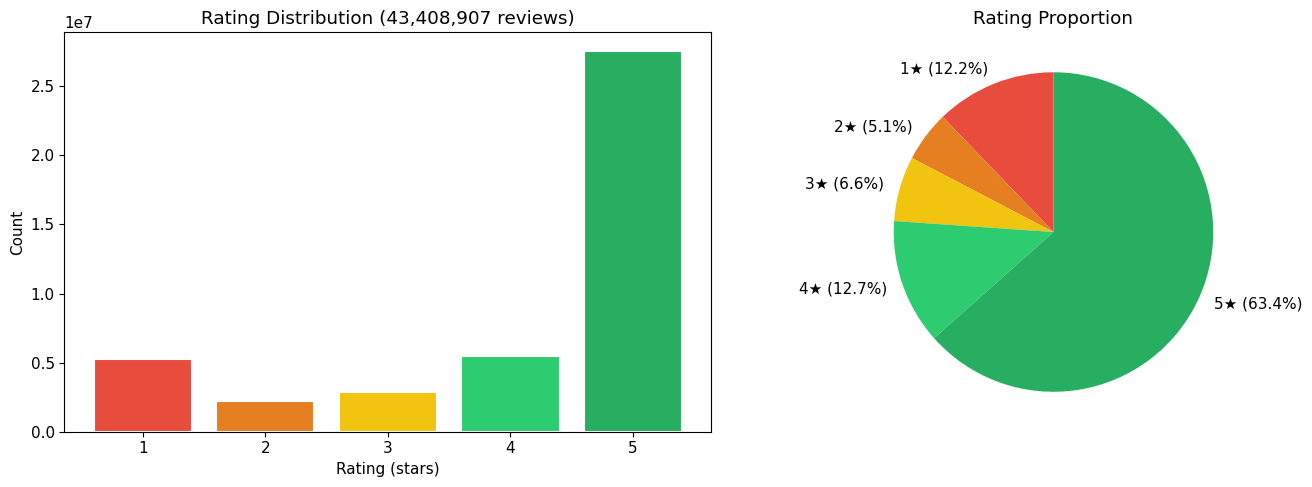

In [28]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Rating Distribution
# ═══════════════════════════════════════════════════════════════
rating_dist = (
    df_rev.groupBy('rating')
    .count()
    .orderBy('rating')
    .collect()
)

ratings = [row['rating'] for row in rating_dist]
counts  = [row['count'] for row in rating_dist]
total_r = sum(counts)
pcts    = [c / total_r * 100 for c in counts]

print("=" * 65)
print("RATING DISTRIBUTION")
print("=" * 65)
print(f"  {'Rating':<10} {'Count':>12} {'%':>8}  {'Bar'}")
print(f"  {'-'*55}")
for r, c, p in zip(ratings, counts, pcts):
    bar = '█' * int(p / 2)
    print(f"  {r:<10} {c:>12,} {p:>7.1f}%  {bar}")

avg_r = sum(r * c for r, c in zip(ratings, counts)) / total_r
print(f"\n  📊 Avg rating: {avg_r:.3f}  |  Total: {total_r:,}")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

axes[0].bar(ratings, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Rating Distribution ({total_r:,} reviews)')
axes[0].set_xticks([1, 2, 3, 4, 5])

labels = [f'{r:.0f}★ ({p:.1f}%)' for r, p in zip(ratings, pcts)]
axes[1].pie(counts, labels=labels, colors=colors, startangle=90)
axes[1].set_title('Rating Proportion')

plt.tight_layout()
plt.show()

## 3️⃣ Silver Reviews — Temporal Distribution (Year / Month)

REVIEWS PER YEAR
  Year            Count        %
  ------------------------------
  1996                1     0.0%
  1998                8     0.0%
  1999              412     0.0%
  2000            3,696     0.0%
  2001            6,754     0.0%
  2002            8,985     0.0%
  2003           12,177     0.0%
  2004           17,397     0.0%
  2005           32,686     0.1%
  2006           53,623     0.1%
  2007          124,039     0.3%
  2008          155,446     0.4%
  2009          207,333     0.5%
  2010          305,725     0.7%
  2011          507,805     1.2%
  2012          791,942     1.8%
  2013        1,696,226     3.9%
  2014        2,452,328     5.6%
  2015        3,371,836     7.8%
  2016        3,719,390     8.6%
  2017        3,753,795     8.6%
  2018        3,870,822     8.9%
  2019        4,915,441    11.3%
  2020        5,664,346    13.0%
  2021        5,376,016    12.4%
  2022        4,475,890    10.3%
  2023        1,884,788     4.3%


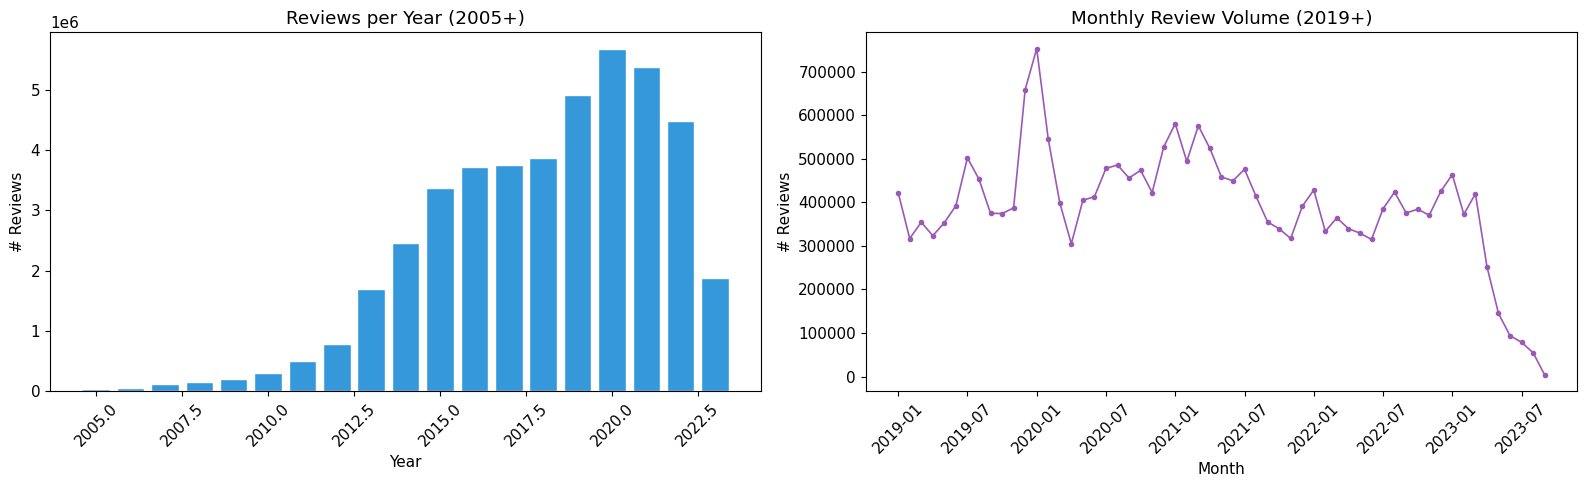

In [29]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Temporal Distribution — Year & Month
# ═══════════════════════════════════════════════════════════════

# ── Yearly ──
year_dist = (
    df_rev.groupBy('review_year')
    .count()
    .orderBy('review_year')
    .collect()
)
years_all   = [row['review_year'] for row in year_dist]
counts_year = [row['count'] for row in year_dist]

print("=" * 70)
print("REVIEWS PER YEAR")
print("=" * 70)
print(f"  {'Year':<8} {'Count':>12} {'%':>8}")
print(f"  {'-'*30}")
for y, c in zip(years_all, counts_year):
    pct = c / total * 100
    print(f"  {y:<8} {c:>12,} {pct:>7.1f}%")

# ── Monthly (2019+) ──
month_dist = (
    df_rev
    .filter(F.col('review_year') >= 2019)
    .groupBy('review_year', 'review_month')
    .count()
    .orderBy('review_year', 'review_month')
    .collect()
)
month_labels = [f"{r['review_year']}-{r['review_month']:02d}" for r in month_dist]
month_counts = [r['count'] for r in month_dist]

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Yearly bar (2005+)
focus_years  = [y for y in years_all if y >= 2005]
focus_counts = [c for y, c in zip(years_all, counts_year) if y >= 2005]
axes[0].bar(focus_years, focus_counts, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('# Reviews')
axes[0].set_title(f'Reviews per Year (2005+)')
axes[0].tick_params(axis='x', rotation=45)

# Monthly line (2019+)
axes[1].plot(range(len(month_labels)), month_counts, '-o', color='#9b59b6',
             linewidth=1.2, markersize=3)
tick_pos = list(range(0, len(month_labels), 6))
tick_lab = [month_labels[i] for i in tick_pos]
axes[1].set_xticks(tick_pos)
axes[1].set_xticklabels(tick_lab, rotation=45)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('# Reviews')
axes[1].set_title('Monthly Review Volume (2019+)')

plt.tight_layout()
plt.show()

## 4️⃣ Silver Reviews — Text Quality (Word Count & Has Text)

TEXT QUALITY ANALYSIS
  Word count:  min=0  max=6349  mean=44.7  median=23
  P75=51  P95=156

  Has text:    43,368,310 (99.9%)
  No text:     40,597 (0.1%)
  ≥ 10 words:  31,808,442 (73.3%)
  ≥ 50 words:  11,162,896 (25.7%)


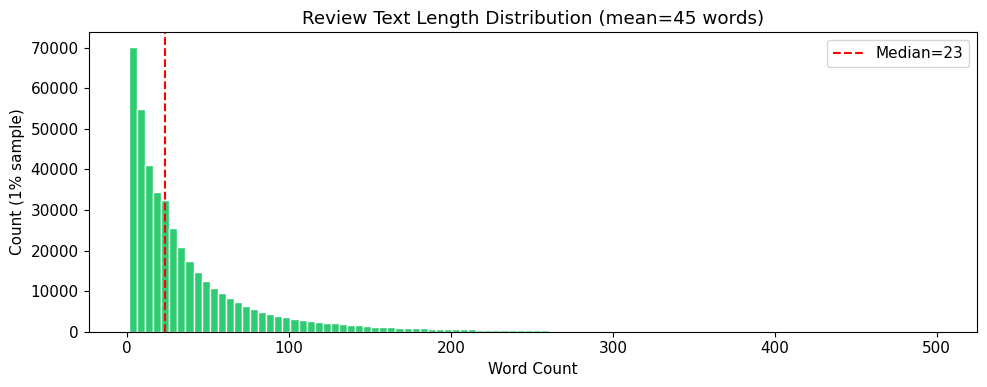

In [30]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Text Quality — Word Count & Has Text
# ═══════════════════════════════════════════════════════════════
text_stats = df_rev.agg(
    F.min('text_word_count').alias('min_wc'),
    F.max('text_word_count').alias('max_wc'),
    F.mean('text_word_count').alias('avg_wc'),
    F.expr("percentile_approx(text_word_count, 0.5)").alias('median_wc'),
    F.expr("percentile_approx(text_word_count, 0.75)").alias('p75_wc'),
    F.expr("percentile_approx(text_word_count, 0.95)").alias('p95_wc'),
    F.count(F.when(F.col('has_text') == True, 1)).alias('with_text'),
    F.count(F.when(F.col('has_text') == False, 1)).alias('no_text'),
    F.count(F.when(F.col('text_word_count') >= 10, 1)).alias('gte_10_words'),
    F.count(F.when(F.col('text_word_count') >= 50, 1)).alias('gte_50_words'),
).collect()[0]

print("=" * 65)
print("TEXT QUALITY ANALYSIS")
print("=" * 65)
print(f"  Word count:  min={text_stats['min_wc']}  max={text_stats['max_wc']}  "
      f"mean={text_stats['avg_wc']:.1f}  median={text_stats['median_wc']}")
print(f"  P75={text_stats['p75_wc']}  P95={text_stats['p95_wc']}")
print(f"\n  Has text:    {text_stats['with_text']:,} ({text_stats['with_text']/total*100:.1f}%)")
print(f"  No text:     {text_stats['no_text']:,} ({text_stats['no_text']/total*100:.1f}%)")
print(f"  ≥ 10 words:  {text_stats['gte_10_words']:,} ({text_stats['gte_10_words']/total*100:.1f}%)")
print(f"  ≥ 50 words:  {text_stats['gte_50_words']:,} ({text_stats['gte_50_words']/total*100:.1f}%)")

# Histogram — sample for plotting
wc_sample = (
    df_rev
    .filter(F.col('text_word_count') > 0)
    .filter(F.col('text_word_count') <= 500)
    .select('text_word_count')
    .sample(fraction=0.01, seed=42)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wc_sample['text_word_count'], bins=100, color='#2ecc71', edgecolor='white')
ax.set_xlabel('Word Count')
ax.set_ylabel('Count (1% sample)')
ax.set_title(f'Review Text Length Distribution (mean={text_stats["avg_wc"]:.0f} words)')
ax.axvline(x=text_stats['median_wc'], color='red', linestyle='--', label=f'Median={text_stats["median_wc"]}')
ax.legend()
plt.tight_layout()
plt.show()

## 5️⃣ Silver Reviews — Verified Purchase & Helpful Vote

VERIFIED PURCHASE & HELPFUL VOTE

📌 VERIFIED PURCHASE
   Verified:       40,105,871 (92.4%)
   Not verified:    3,303,036 (7.6%)
   → Variance: ✅ Đủ

👍 HELPFUL VOTE
   Range:   -4 – 46841  |  Mean: 1.09
   = 0:       34,089,099 (78.5%)
   ≥ 1:        9,319,804 (21.5%)
   ≥ 5:        1,595,258 (3.7%)
   ≥ 10:         742,278 (1.7%)


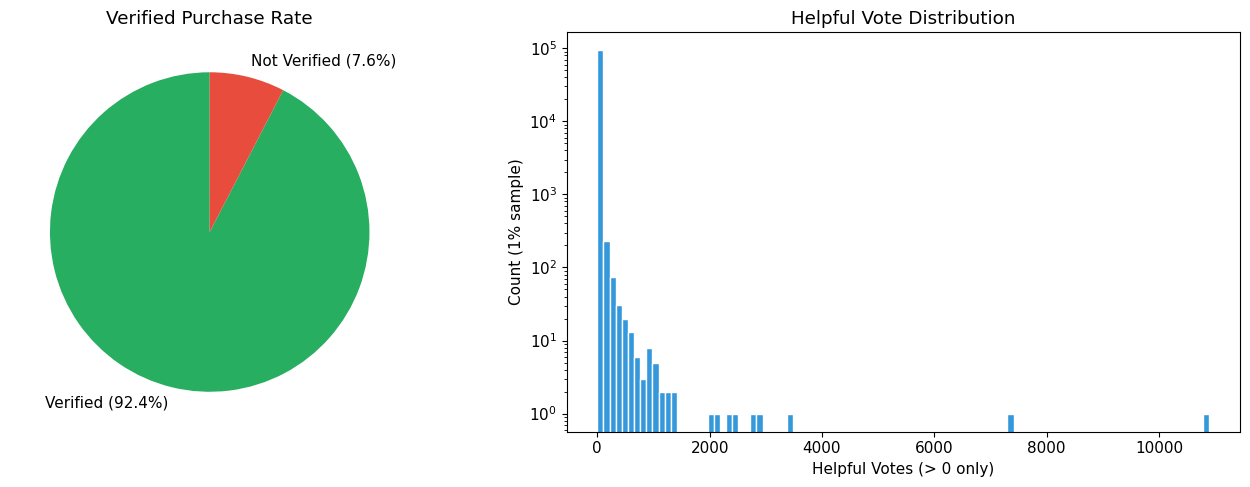

In [31]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Verified Purchase & Helpful Vote
# ═══════════════════════════════════════════════════════════════
vp_stats = df_rev.agg(
    F.count(F.when(F.col('verified_purchase') == True, 1)).alias('verified'),
    F.count(F.when(F.col('verified_purchase') == False, 1)).alias('not_verified'),
    F.min('helpful_vote').alias('min_hv'),
    F.max('helpful_vote').alias('max_hv'),
    F.mean('helpful_vote').alias('avg_hv'),
    F.count(F.when(F.col('helpful_vote') == 0, 1)).alias('hv_zero'),
    F.count(F.when(F.col('helpful_vote') >= 1, 1)).alias('hv_gte1'),
    F.count(F.when(F.col('helpful_vote') >= 5, 1)).alias('hv_gte5'),
    F.count(F.when(F.col('helpful_vote') >= 10, 1)).alias('hv_gte10'),
).collect()[0]

vr = vp_stats['verified'] / total

print("=" * 65)
print("VERIFIED PURCHASE & HELPFUL VOTE")
print("=" * 65)
print(f"\n📌 VERIFIED PURCHASE")
print(f"   Verified:     {vp_stats['verified']:>12,} ({vr*100:.1f}%)")
print(f"   Not verified: {vp_stats['not_verified']:>12,} ({(1-vr)*100:.1f}%)")
print(f"   → Variance: {'✅ Đủ' if 0.3 < vr < 0.95 else '⚠️ Ít variance'}")

print(f"\n👍 HELPFUL VOTE")
print(f"   Range:   {vp_stats['min_hv']} – {vp_stats['max_hv']}  |  Mean: {vp_stats['avg_hv']:.2f}")
print(f"   = 0:     {vp_stats['hv_zero']:>12,} ({vp_stats['hv_zero']/total*100:.1f}%)")
print(f"   ≥ 1:     {vp_stats['hv_gte1']:>12,} ({vp_stats['hv_gte1']/total*100:.1f}%)")
print(f"   ≥ 5:     {vp_stats['hv_gte5']:>12,} ({vp_stats['hv_gte5']/total*100:.1f}%)")
print(f"   ≥ 10:    {vp_stats['hv_gte10']:>12,} ({vp_stats['hv_gte10']/total*100:.1f}%)")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Verified pie
axes[0].pie(
    [vp_stats['verified'], vp_stats['not_verified']],
    labels=[f"Verified ({vr*100:.1f}%)", f"Not Verified ({(1-vr)*100:.1f}%)"],
    colors=['#27ae60', '#e74c3c'], startangle=90
)
axes[0].set_title('Verified Purchase Rate')

# Helpful vote histogram (sample)
hv_sample = (
    df_rev
    .filter(F.col('helpful_vote') > 0)
    .select('helpful_vote')
    .sample(fraction=0.01, seed=42)
    .toPandas()
)
axes[1].hist(hv_sample['helpful_vote'], bins=100, color='#3498db', edgecolor='white')
axes[1].set_xlabel('Helpful Votes (> 0 only)')
axes[1].set_ylabel('Count (1% sample)')
axes[1].set_title('Helpful Vote Distribution')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 6️⃣ Silver Reviews — Duplicate Check & Unique Counts

In [32]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Duplicate Check & Unique Users/Items
# ═══════════════════════════════════════════════════════════════
dedup_stats = df_rev.agg(
    F.count('*').alias('total_rows'),
    F.countDistinct('parent_asin', 'user_id', 'review_ts').alias('distinct_keys'),
    F.countDistinct('user_id').alias('unique_users'),
    F.countDistinct('parent_asin').alias('unique_items'),
).collect()[0]

dup_count = dedup_stats['total_rows'] - dedup_stats['distinct_keys']

print("=" * 65)
print("DUPLICATE CHECK & UNIQUE COUNTS")
print("=" * 65)
print(f"  Total rows:        {dedup_stats['total_rows']:>12,}")
print(f"  Distinct keys:     {dedup_stats['distinct_keys']:>12,}  (parent_asin + user_id + review_ts)")
print(f"  Duplicates:        {dup_count:>12,}  ({dup_count/dedup_stats['total_rows']*100:.3f}%)")
print(f"  → {'✅ No duplicates' if dup_count == 0 else '⚠️ Duplicates found!'}")
print(f"\n  Unique users:      {dedup_stats['unique_users']:>12,}")
print(f"  Unique items:      {dedup_stats['unique_items']:>12,}")
print(f"  Avg reviews/user:  {dedup_stats['total_rows']/dedup_stats['unique_users']:.1f}")
print(f"  Avg reviews/item:  {dedup_stats['total_rows']/dedup_stats['unique_items']:.1f}")

DUPLICATE CHECK & UNIQUE COUNTS
  Total rows:          43,408,907
  Distinct keys:       43,408,907  (parent_asin + user_id + review_ts)
  Duplicates:                   0  (0.000%)
  → ✅ No duplicates

  Unique users:        18,286,190
  Unique items:         1,609,860
  Avg reviews/user:  2.4
  Avg reviews/item:  27.0


In [33]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Sample Records Preview — Reviews
# ═══════════════════════════════════════════════════════════════
print("📋 10 SAMPLE REVIEW RECORDS:")
df_rev.show(10, truncate=40)

print("\n📋 SINGLE RECORD (vertical view):")
df_rev.limit(1).toPandas().T

📋 10 SAMPLE REVIEW RECORDS:
+-----------+----------------------------+------+----------------------------------------+----------------------------------------+---------------+-----------------------+------------+-----------------+--------+-----------+------------+
|parent_asin|                     user_id|rating|                             title_clean|                              text_clean|text_word_count|              review_ts|helpful_vote|verified_purchase|has_text|review_year|review_month|
+-----------+----------------------------+------+----------------------------------------+----------------------------------------+---------------+-----------------------+------------+-----------------+--------+-----------+------------+
| 0062970704|AE3ZDO4BZPD56KZDJHEFDB3DGHOQ|   5.0|                         buy this book!!|          funniest book ever! love it!!!|              5|2020-01-06 01:48:57.504|           0|             true|    true|       2020|           1|
| 0062970704|AE3I4QADYMU

,0
parent_asin,0062970704
user_id,AE3ZDO4BZPD56KZDJHEFDB3DGHOQ
rating,5.0
title_clean,buy this book!!
text_clean,funniest book ever! love it!!!
text_word_count,5
review_ts,2020-01-06 01:48:57.504000
helpful_vote,0
verified_purchase,True
has_text,True


---

## 7️⃣ Silver Metadata — Schema, Statistics & Price

In [34]:
# ═══════════════════════════════════════════════════════════════
# CELL 11: Load Silver Metadata — Schema
# ═══════════════════════════════════════════════════════════════
df_meta = spark.read.parquet(SILVER_META_PATH)

print("📋 Silver Metadata Schema:")
df_meta.printSchema()
print(f"Partitions: {df_meta.rdd.getNumPartitions()}")

📋 Silver Metadata Schema:
root
 |-- parent_asin: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: float (nullable = true)
 |-- rating_number: integer (nullable = true)
 |-- price_numeric: double (nullable = true)
 |-- price_raw: string (nullable = true)
 |-- store: string (nullable = true)
 |-- features: string (nullable = true)
 |-- description: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- bought_together: string (nullable = true)

Partitions: 12


SILVER METADATA — STATISTICS

  Total products:       1,610,012

💰 PRICE ANALYSIS
   Coverage:    526,499 (32.7%)
   Range:       $0.00 – $44630.00
   Mean:        $96.45  |  Median: $22.90

   📊 Price segments:
      < $50:           377,477 (71.7%)
      $50–$120:         68,587 (13.0%)
      > $120:           80,435 (15.3%)

⭐ AVERAGE RATING:  1.0 – 5.0  (mean: 4.01)
📊 RATING NUMBER:   1 – 1,034,896  (mean: 180.5)


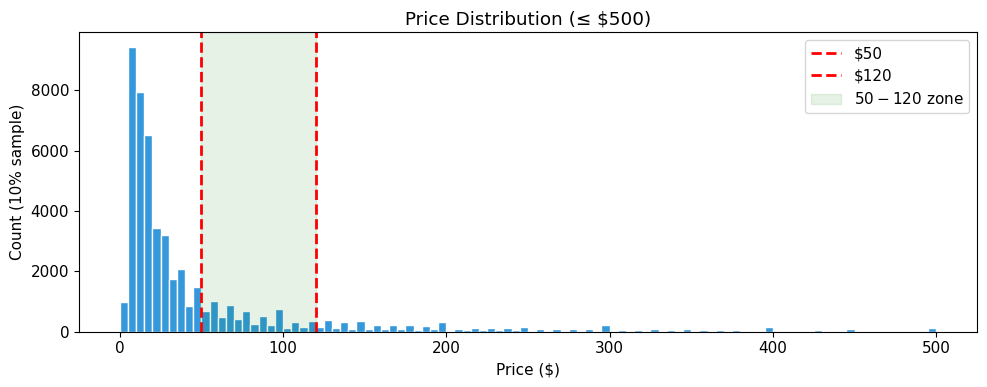

In [35]:
# ═══════════════════════════════════════════════════════════════
# CELL 12: Metadata — Statistics & Price Coverage
# ═══════════════════════════════════════════════════════════════
meta_stats = df_meta.agg(
    F.count('*').alias('total'),
    F.count('price_numeric').alias('has_price'),
    (F.count('price_numeric') / F.count('*') * 100).alias('price_pct'),
    F.min('price_numeric').alias('min_price'),
    F.max('price_numeric').alias('max_price'),
    F.mean('price_numeric').alias('avg_price'),
    F.expr("percentile_approx(price_numeric, 0.5)").alias('median_price'),
    F.min('average_rating').alias('min_avg_rating'),
    F.max('average_rating').alias('max_avg_rating'),
    F.mean('average_rating').alias('avg_avg_rating'),
    F.min('rating_number').alias('min_rn'),
    F.max('rating_number').alias('max_rn'),
    F.mean('rating_number').alias('avg_rn'),
    F.count(F.when(F.col('price_numeric') < 50, 1)).alias('price_lt50'),
    F.count(F.when((F.col('price_numeric') >= 50) & (F.col('price_numeric') <= 120), 1)).alias('price_50_120'),
    F.count(F.when(F.col('price_numeric') > 120, 1)).alias('price_gt120'),
).collect()[0]

meta_total = meta_stats['total']

print("=" * 70)
print("SILVER METADATA — STATISTICS")
print("=" * 70)
print(f"\n  Total products:    {meta_total:>12,}")
print(f"\n💰 PRICE ANALYSIS")
print(f"   Coverage:    {meta_stats['has_price']:,} ({meta_stats['price_pct']:.1f}%)")
print(f"   Range:       ${meta_stats['min_price']:.2f} – ${meta_stats['max_price']:.2f}")
print(f"   Mean:        ${meta_stats['avg_price']:.2f}  |  Median: ${meta_stats['median_price']:.2f}")
print(f"\n   📊 Price segments:")
hp = meta_stats['has_price']
print(f"      < $50:        {meta_stats['price_lt50']:>10,} ({meta_stats['price_lt50']/hp*100:.1f}%)")
print(f"      $50–$120:     {meta_stats['price_50_120']:>10,} ({meta_stats['price_50_120']/hp*100:.1f}%)")
print(f"      > $120:       {meta_stats['price_gt120']:>10,} ({meta_stats['price_gt120']/hp*100:.1f}%)")

print(f"\n⭐ AVERAGE RATING:  {meta_stats['min_avg_rating']:.1f} – {meta_stats['max_avg_rating']:.1f}  "
      f"(mean: {meta_stats['avg_avg_rating']:.2f})")
print(f"📊 RATING NUMBER:   {meta_stats['min_rn']:,} – {meta_stats['max_rn']:,}  "
      f"(mean: {meta_stats['avg_rn']:.1f})")

# Price histogram
price_sample = (
    df_meta
    .filter(F.col('price_numeric').isNotNull())
    .filter(F.col('price_numeric') <= 500)
    .select('price_numeric')
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(price_sample['price_numeric'], bins=100, color='#3498db', edgecolor='white')
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='$50')
ax.axvline(x=120, color='red', linestyle='--', linewidth=2, label='$120')
ax.axvspan(50, 120, alpha=0.1, color='green', label='$50-$120 zone')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count (10% sample)')
ax.set_title('Price Distribution (≤ $500)')
ax.legend()
plt.tight_layout()
plt.show()

STORE/BRAND DISTRIBUTION
  Has store:       1,600,490 (99.4%)
  Null/empty:          9,522 (0.6%)
  Unique stores:     142,186

  Top 20 stores/brands:
      1. Amazon Renewed                        30,576
      2. HP                                    17,129
      3. Sony                                  14,160
      4. Generic                               13,499
      5. SAMSUNG                               11,503
      6. Lenovo                                 9,049
      7. Dell                                   7,042
      8. ASUS                                   6,870
      9. Neewer                                 6,755
     10. Fintie                                 5,370
     11. Canon                                  5,125
     12. UPBRIGHT                               4,574
     13. uxcell                                 4,386
     14. Panasonic                              4,039
     15. Kastar                                 3,679
     16. Garmin                       

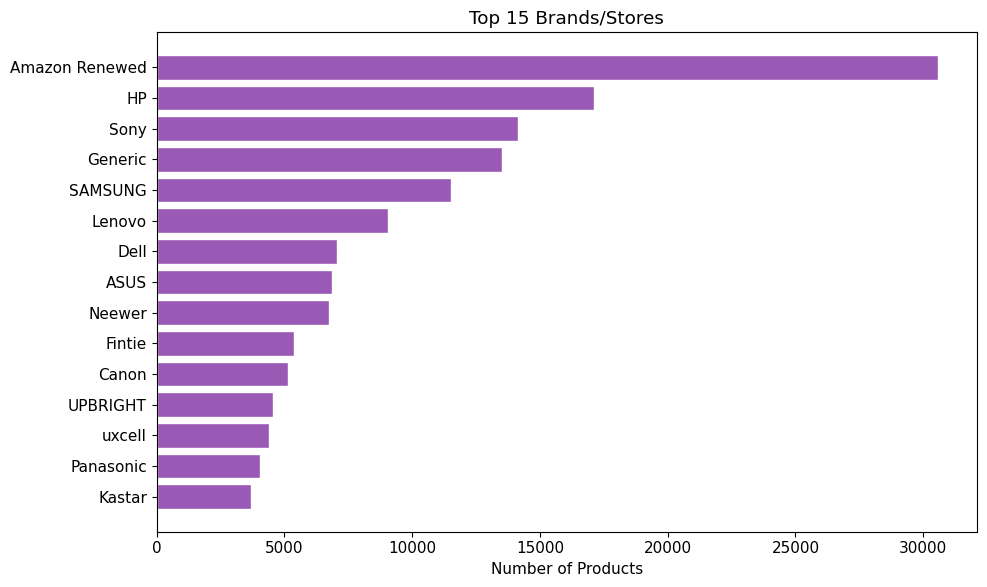

In [36]:
# ═══════════════════════════════════════════════════════════════
# CELL 13: Metadata — Store/Brand Distribution
# ═══════════════════════════════════════════════════════════════
store_stats = df_meta.agg(
    F.count(F.when(F.col('store').isNotNull() & (F.col('store') != ''), 1)).alias('has_store'),
    F.count(F.when(F.col('store').isNull() | (F.col('store') == ''), 1)).alias('null_store'),
    F.countDistinct('store').alias('unique_stores'),
).collect()[0]

print("=" * 65)
print("STORE/BRAND DISTRIBUTION")
print("=" * 65)
print(f"  Has store:      {store_stats['has_store']:>10,} ({store_stats['has_store']/meta_total*100:.1f}%)")
print(f"  Null/empty:     {store_stats['null_store']:>10,} ({store_stats['null_store']/meta_total*100:.1f}%)")
print(f"  Unique stores:  {store_stats['unique_stores']:>10,}")

print(f"\n  Top 20 stores/brands:")
top_stores = (
    df_meta
    .filter(F.col('store').isNotNull() & (F.col('store') != ''))
    .groupBy('store')
    .count()
    .orderBy(F.col('count').desc())
    .limit(20)
    .collect()
)
for rank, row in enumerate(top_stores, 1):
    print(f"    {rank:>3}. {row['store']:<35} {row['count']:>8,}")

# Bar chart top 15
fig, ax = plt.subplots(figsize=(10, 6))
brands = [r['store'] for r in top_stores[:15]]
bcounts = [r['count'] for r in top_stores[:15]]
ax.barh(brands[::-1], bcounts[::-1], color='#9b59b6', edgecolor='white')
ax.set_xlabel('Number of Products')
ax.set_title('Top 15 Brands/Stores')
plt.tight_layout()
plt.show()

In [37]:
# ═══════════════════════════════════════════════════════════════
# CELL 14: Metadata — Category Distribution
# ═══════════════════════════════════════════════════════════════
cat_dist = (
    df_meta
    .groupBy('main_category')
    .count()
    .orderBy(F.col('count').desc())
    .collect()
)

print("=" * 65)
print("CATEGORY DISTRIBUTION")
print("=" * 65)
print(f"  {'Category':<40} {'Count':>10} {'%':>8}")
print(f"  {'-'*60}")
for row in cat_dist:
    cat = row['main_category'] if row['main_category'] else '(NULL)'
    pct = row['count'] / meta_total * 100
    print(f"  {cat:<40} {row['count']:>10,} {pct:>7.1f}%")

CATEGORY DISTRIBUTION
  Category                                      Count        %
  ------------------------------------------------------------
  Computers                                   418,868    26.0%
  All Electronics                             376,435    23.4%
  Camera & Photo                              223,690    13.9%
  Cell Phones & Accessories                   138,237     8.6%
  Home Audio & Theater                        106,516     6.6%
  (NULL)                                      106,334     6.6%
  Industrial & Scientific                      50,555     3.1%
  Car Electronics                              27,332     1.7%
  Tools & Home Improvement                     24,042     1.5%
  Amazon Home                                  21,299     1.3%
  Office Products                              21,250     1.3%
  AMAZON FASHION                               18,391     1.1%
  Sports & Outdoors                            14,581     0.9%
  Automotive                     

METADATA — NULL RATES PER FIELD
  Field                  Null/Empty     Rate  Status
  -------------------------------------------------------
  parent_asin                     0     0.0%  ✅ OK
  main_category             106,334     6.6%  ⚠️ Warn
  title                          94     0.0%  ✅ OK
  average_rating                  0     0.0%  ✅ OK
  rating_number                   0     0.0%  ✅ OK
  price_numeric           1,083,513    67.3%  ❌ High
  price_raw                       0     0.0%  ✅ OK
  store                       9,522     0.6%  ✅ OK
  features                  423,041    26.3%  ⚠️ Warn
  description               682,749    42.4%  ❌ High
  categories                128,442     8.0%  ⚠️ Warn
  bought_together         1,610,012   100.0%  ❌ High


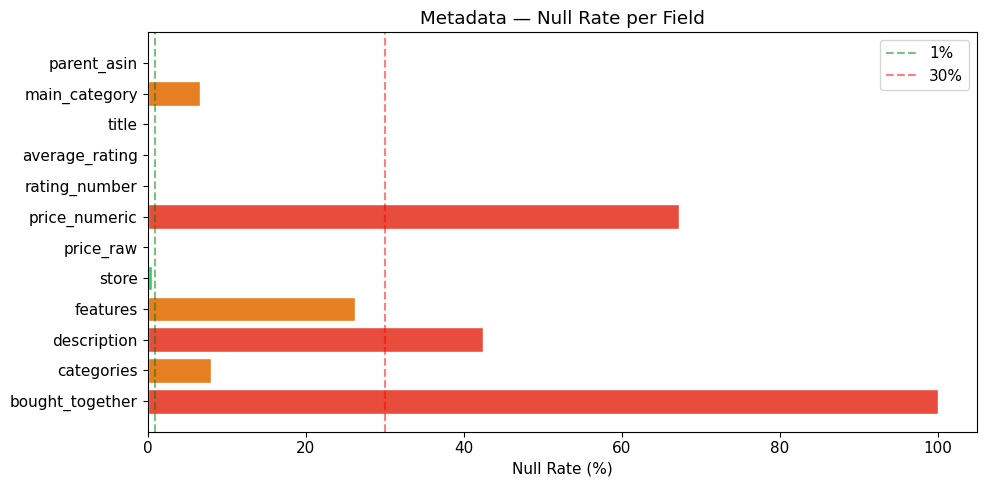

In [38]:
# ═══════════════════════════════════════════════════════════════
# CELL 15: Metadata — Null Rate per Field
# ═══════════════════════════════════════════════════════════════
meta_cols = df_meta.columns
null_exprs = [
    F.count(
        F.when(F.col(c).isNull() | (F.col(c) == '') | (F.col(c).cast('string') == 'NaN'), 1)
    ).alias(f'null_{c}')
    for c in meta_cols
]
null_result = df_meta.agg(*null_exprs).collect()[0]

print("=" * 65)
print("METADATA — NULL RATES PER FIELD")
print("=" * 65)
print(f"  {'Field':<22} {'Null/Empty':>10} {'Rate':>8}  {'Status'}")
print(f"  {'-'*55}")

null_data = []
for c in meta_cols:
    cnt = null_result[f'null_{c}']
    rate = cnt / meta_total * 100
    status = '✅ OK' if rate < 1 else ('⚠️ Warn' if rate < 30 else '❌ High')
    null_data.append((c, cnt, rate))
    print(f"  {c:<22} {cnt:>10,} {rate:>7.1f}%  {status}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
field_names = [d[0] for d in null_data]
null_rates  = [d[2] for d in null_data]
colors_bar  = ['#e74c3c' if r > 30 else '#e67e22' if r > 1 else '#2ecc71' for r in null_rates]
ax.barh(field_names[::-1], null_rates[::-1], color=colors_bar[::-1], edgecolor='white')
ax.set_xlabel('Null Rate (%)')
ax.set_title('Metadata — Null Rate per Field')
ax.axvline(x=1, color='green', linestyle='--', alpha=0.5, label='1%')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30%')
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
# ═══════════════════════════════════════════════════════════════
# CELL 16: Metadata — Sample Records Preview
# ═══════════════════════════════════════════════════════════════
print("📋 10 SAMPLE METADATA RECORDS:")
df_meta.show(10)

print("\n📋 SINGLE RECORD (vertical view):")
df_meta.limit(1).toPandas().T

📋 10 SAMPLE METADATA RECORDS:
+-----------+-------------+--------------------+--------------+-------------+-------------+---------+------------------+--------------------+--------------------+--------------------+---------------+
|parent_asin|main_category|               title|average_rating|rating_number|price_numeric|price_raw|             store|            features|         description|          categories|bought_together|
+-----------+-------------+--------------------+--------------+-------------+-------------+---------+------------------+--------------------+--------------------+--------------------+---------------+
| 0312984294|             |     The Corrections|           3.8|            5|         6.27|     6.27|           Picador|                    |After almost 50 y...|Electronics | eBo...|               |
| 0594017343|             |Barnes Noble Nook...|           1.0|            1|         NULL|     None|  Barnes and Noble|                    |                    |Electron

,0
parent_asin,0312984294
main_category,
title,The Corrections
average_rating,3.8
rating_number,5
price_numeric,6.27
price_raw,6.27
store,Picador
features,
description,"After almost 50 years as a wife and mother, En..."


---

## 8️⃣ Cross-Layer Join — Reviews × Metadata Coverage

In [40]:
# ═══════════════════════════════════════════════════════════════
# CELL 17: Cross-Layer — Reviews × Metadata Coverage
# ═══════════════════════════════════════════════════════════════
rev_asins  = df_rev.select('parent_asin').distinct()
meta_asins = df_meta.select('parent_asin').distinct()

rev_asin_count  = rev_asins.count()
meta_asin_count = meta_asins.count()

# Orphan reviews: ASINs in reviews but NOT in metadata
orphans = rev_asins.join(meta_asins, 'parent_asin', 'left_anti')
orphan_count = orphans.count()
coverage = (rev_asin_count - orphan_count) / rev_asin_count * 100

print("=" * 65)
print("CROSS-LAYER JOIN COVERAGE")
print("=" * 65)
print(f"  Unique ASINs in Reviews:   {rev_asin_count:>12,}")
print(f"  Unique ASINs in Metadata:  {meta_asin_count:>12,}")
print(f"  Orphan ASINs (no meta):    {orphan_count:>12,}")
print(f"  Coverage rate:             {coverage:>11.1f}%")
print(f"  → {'✅ Excellent' if coverage >= 95 else '⚠️ Some orphans — may need fallback' if coverage >= 80 else '❌ Low coverage'}")

if orphan_count > 0:
    print(f"\n  📋 Sample orphan ASINs (first 10):")
    orphans.show(10, truncate=False)

CROSS-LAYER JOIN COVERAGE
  Unique ASINs in Reviews:      1,609,860
  Unique ASINs in Metadata:     1,610,012
  Orphan ASINs (no meta):               0
  Coverage rate:                   100.0%
  → ✅ Excellent


## 9️⃣ Silver File Size Analysis (MinIO)

In [41]:
# ═══════════════════════════════════════════════════════════════
# CELL 18: Silver File Size Analysis via MinIO Client
# ═══════════════════════════════════════════════════════════════
client = get_minio_client()
bucket = 'electronics-silver'

print("=" * 70)
print("SILVER FILE SIZE ANALYSIS (MinIO)")
print("=" * 70)

for prefix, label in [('reviews/', 'Reviews'), ('metadata/', 'Metadata')]:
    objects = list(client.list_objects(bucket, prefix=prefix, recursive=True))
    parquet_files = [o for o in objects if o.object_name.endswith('.parquet')]
    
    if not parquet_files:
        print(f"\n  ⚠️ {label}: No parquet files found at {prefix}")
        continue
    
    sizes_mb = [o.size / (1024**2) for o in parquet_files]
    total_gb = sum(sizes_mb) / 1024
    avg_mb   = sum(sizes_mb) / len(sizes_mb)
    
    # Count partition directories for reviews
    dirs = set()
    for o in objects:
        parts = o.object_name.split('/')
        if len(parts) >= 3:
            dirs.add('/'.join(parts[:3]))
    
    print(f"\n📁 {label.upper()}")
    print(f"   Parquet files:  {len(parquet_files):>8}")
    print(f"   Partition dirs: {len(dirs):>8}")
    print(f"   File sizes:     Min={min(sizes_mb):.1f}MB | Max={max(sizes_mb):.1f}MB | Avg={avg_mb:.1f}MB")
    print(f"   Total size:     {total_gb:.2f} GB")
    print(f"   Optimal range:  {'✅ 32–256 MB' if 32 <= avg_mb <= 256 else '⚠️ Consider compaction'}")

SILVER FILE SIZE ANALYSIS (MinIO)

📁 REVIEWS
   Parquet files:       298
   Partition dirs:      298
   File sizes:     Min=0.0MB | Max=69.0MB | Avg=17.5MB
   Total size:     5.10 GB
   Optimal range:  ⚠️ Consider compaction

📁 METADATA
   Parquet files:         4
   Partition dirs:        0
   File sizes:     Min=26.5MB | Max=247.7MB | Avg=121.2MB
   Total size:     0.47 GB
   Optimal range:  ✅ 32–256 MB


---

## 🔟 Summary Dashboard — Key Metrics

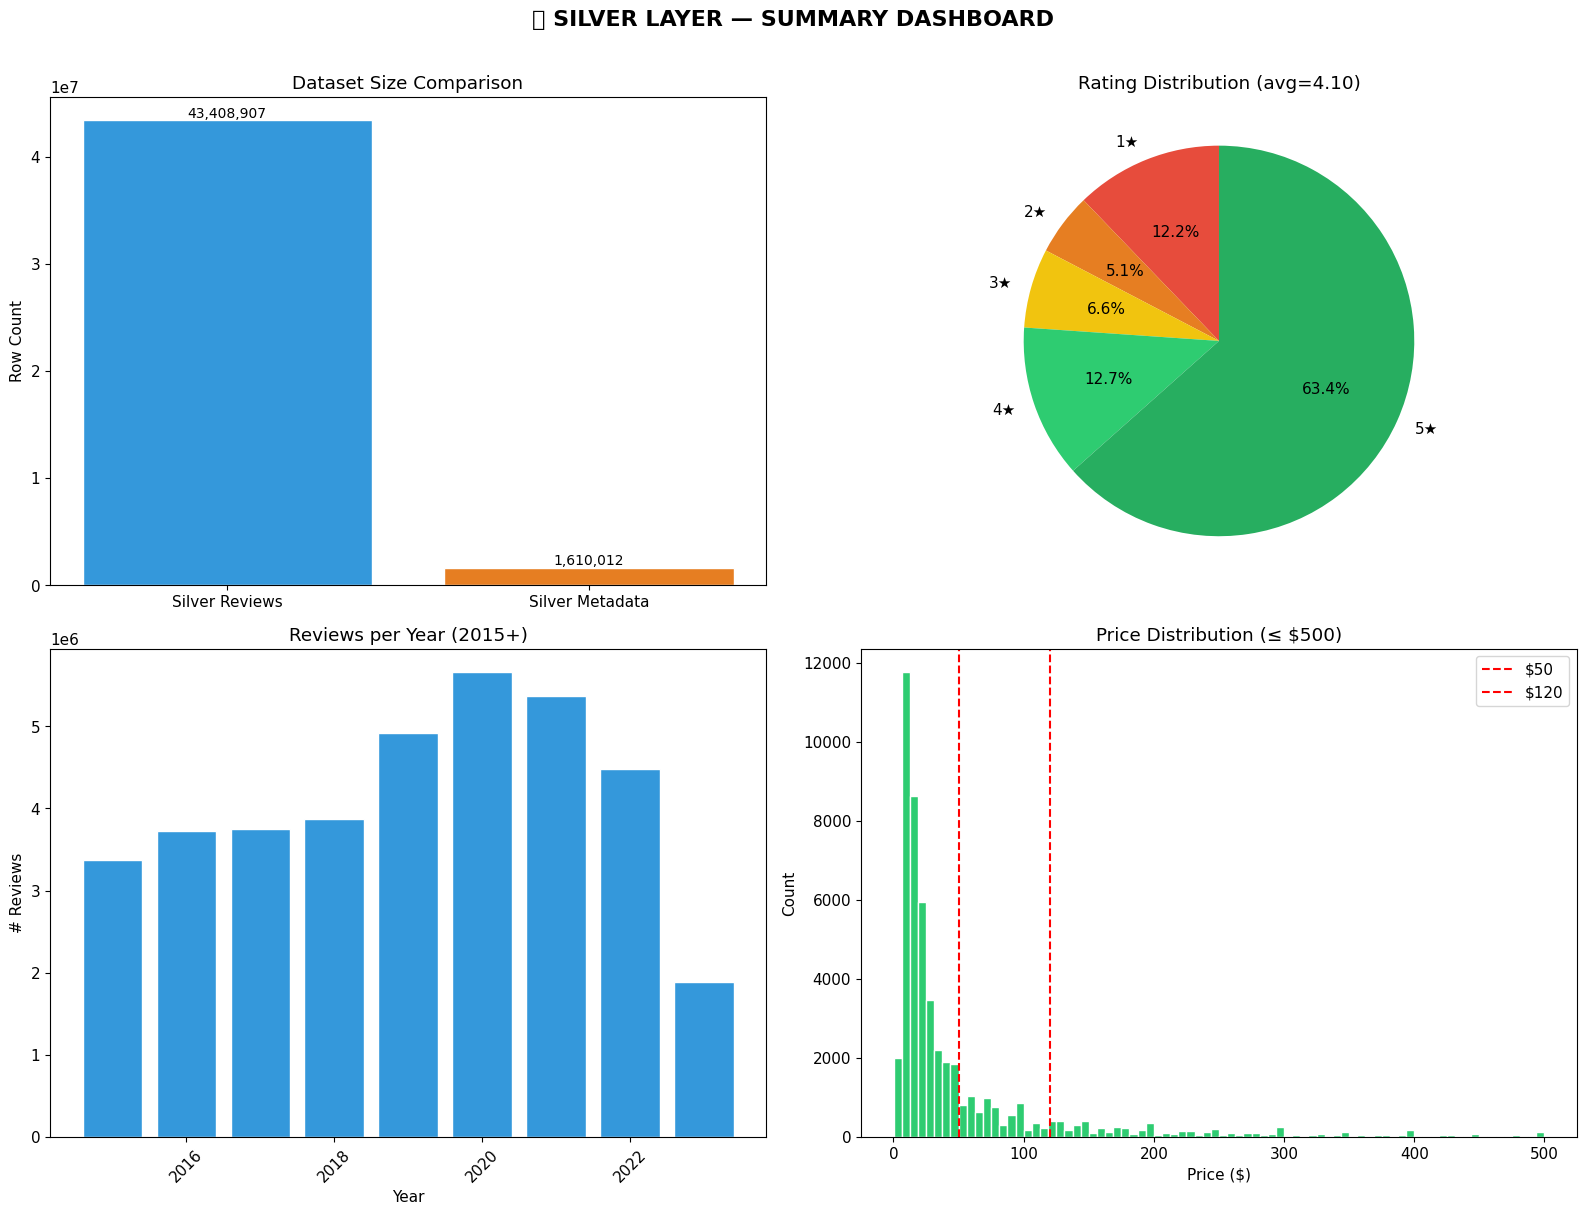

📊 SILVER LAYER — FINAL SUMMARY
  Metric                                             Value
  ---------------------------------------------------------
  Total Reviews                                 43,408,907
  Total Metadata Products                        1,610,012
  Unique Users                                  18,286,190
  Unique Items (Reviews)                         1,609,860
  Year Range                                   1996 – 2023
  Avg Rating                                         4.100
  Verified Rate                                      92.4%
  Price Coverage (Metadata)                          32.7%
  Reviews ↔ Metadata Coverage                       100.0%
  Duplicates (Reviews)                                   0
  ✅ Silver layer sẵn sàng cho Phase 2 — Feature Engineering


In [42]:
# ═══════════════════════════════════════════════════════════════
# CELL 19: Summary Dashboard — 2×2 Visualization + Final Table
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Reviews vs Metadata bar
axes[0, 0].bar(
    ['Silver Reviews', 'Silver Metadata'],
    [total, meta_total],
    color=['#3498db', '#e67e22'], edgecolor='white'
)
axes[0, 0].set_ylabel('Row Count')
axes[0, 0].set_title('Dataset Size Comparison')
for i, v in enumerate([total, meta_total]):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# (2) Rating pie
colors_pie = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
labels_pie = [f'{r:.0f}★' for r in ratings]
axes[0, 1].pie(counts, labels=labels_pie, colors=colors_pie, startangle=90,
               autopct='%1.1f%%')
axes[0, 1].set_title(f'Rating Distribution (avg={avg_r:.2f})')

# (3) Reviews per year (2015+)
fy = [y for y in years_all if y >= 2015]
fc = [c for y, c in zip(years_all, counts_year) if y >= 2015]
axes[1, 0].bar(fy, fc, color='#3498db', edgecolor='white')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('# Reviews')
axes[1, 0].set_title('Reviews per Year (2015+)')
axes[1, 0].tick_params(axis='x', rotation=45)

# (4) Price histogram
if len(price_sample) > 0:
    axes[1, 1].hist(price_sample['price_numeric'], bins=80, color='#2ecc71', edgecolor='white')
    axes[1, 1].axvline(x=50, color='red', linestyle='--', label='$50')
    axes[1, 1].axvline(x=120, color='red', linestyle='--', label='$120')
    axes[1, 1].set_xlabel('Price ($)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Price Distribution (≤ $500)')
    axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, 'No price data', ha='center', va='center')

plt.suptitle('📊 SILVER LAYER — SUMMARY DASHBOARD', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Final Summary Table ──
print("=" * 70)
print("📊 SILVER LAYER — FINAL SUMMARY")
print("=" * 70)
print(f"  {'Metric':<35} {'Value':>20}")
print(f"  {'-'*57}")
print(f"  {'Total Reviews':<35} {total:>20,}")
print(f"  {'Total Metadata Products':<35} {meta_total:>20,}")
print(f"  {'Unique Users':<35} {dedup_stats['unique_users']:>20,}")
print(f"  {'Unique Items (Reviews)':<35} {dedup_stats['unique_items']:>20,}")
print(f"  {'Year Range':<35} {str(rev_stats['min_year']) + ' – ' + str(rev_stats['max_year']):>20}")
print(f"  {'Avg Rating':<35} {rev_stats['avg_rating']:>20.3f}")
print(f"  {'Verified Rate':<35} {vr*100:>19.1f}%")
print(f"  {'Price Coverage (Metadata)':<35} {meta_stats['price_pct']:>19.1f}%")
print(f"  {'Reviews ↔ Metadata Coverage':<35} {coverage:>19.1f}%")
print(f"  {'Duplicates (Reviews)':<35} {dup_count:>20,}")
print(f"{'='*70}")
print(f"  ✅ Silver layer sẵn sàng cho Phase 2 — Feature Engineering")